In [207]:
import os
import sys
import numpy as np
import time
import scipy
import matplotlib.pyplot as plt
import time

from frank.utilities import UVDataBinner

In [208]:
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD143006 = {'inc':18.6, 'pa':169 , 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout':0.518*2, 'disk_name': 'HD143006'}

data_dic = AS209

dir = "/Users/mariajmelladot/Desktop/Frank2D/data/uvtables/"
disk_name = data_dic['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"


# Huang 2018 
inc = data_dic['inc']
pa = data_dic['pa']
dra = data_dic['dra']
ddec = data_dic['ddec']
r_out = data_dic['rout']

# Frank Parameters
N = 50
 # load data
data = np.load(data_file)

In [209]:
u, v, Re, Imag, Weights = data['u'], data['v'], data['Re'], data['Im'], data['w']
Vis = Re + Imag*1j


In [210]:
baselines = np.hypot(u, v)         
grid = np.logspace(np.log10(min(baselines.min(), baselines[0])),
                           np.log10(max(baselines.max(), baselines[-1])),
                           10**4)

cs, ms = ['#a4a4a4', 'k'], ['.', 'x']
bin_widths=[1e3, 1e5]
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])


In [211]:
def power_spectrum(x, m, c):
    return c*(x**m)

In [212]:
def linear(log_x, m, c):
    return m*log_x + np.log10(c)

In [213]:
m_best1, c_best1 =  -6, 1e30
m_best2, c_best2 =  -1.9, 1e4 #-2, 1e8

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_70424/583319058.py:4: RuntimeWarning: divide by zero encountered in log10
  logy = np.log10(y)
/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_70424/583319058.py:5: RuntimeWarning: divide by zero encountered in log10
  logx = np.log10(x)


<Figure size 640x480 with 0 Axes>

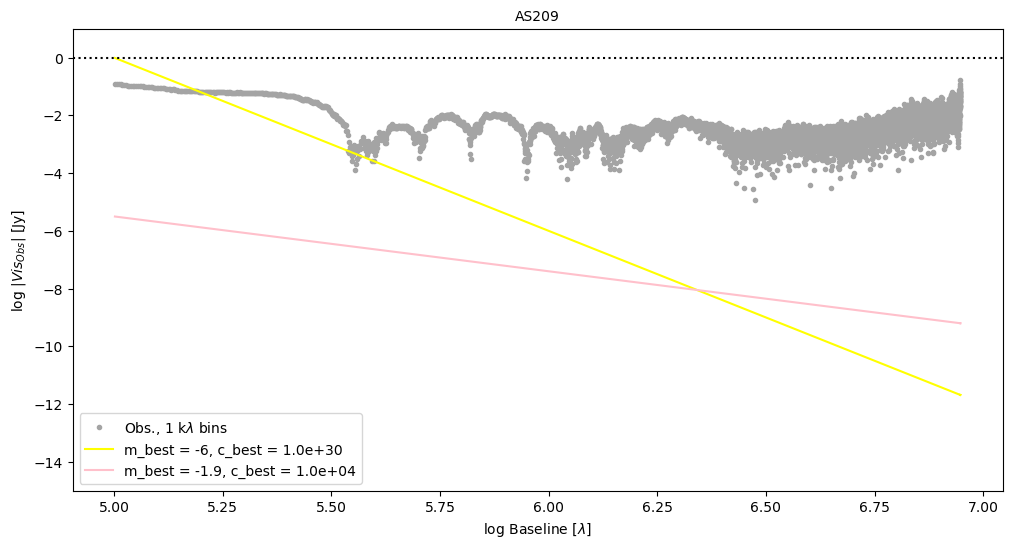

In [215]:
x = binned_vis.uv[100:]
y = np.abs(binned_vis.V[100:])**2

logy = np.log10(y)
logx = np.log10(x)

plt.clf()
plt.figure(figsize=(12, 6))
plt.plot(logx, logy, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(logx, linear(logx, m_best1, c_best1), c = 'yellow', ls = '-', label = f'm_best = {m_best1}, c_best = {c_best1:.1e}')
plt.plot(logx, linear(logx, m_best2, c_best2), c = 'pink',  ls = '-',  label = f'm_best = {m_best2}, c_best = {c_best2:.1e}')

plt.axhline(0, c='black', ls=':')
plt.title( data_dic['disk_name'], size = 10)    
plt.xlabel(r'log Baseline [$\lambda$]', size = 10)
plt.ylabel(r'log $|Vis_{Obs}|$ [Jy]', size = 10)
plt.legend(loc = 'best')
plt.ylim(-15, 1)
plt.show()

## lines in de (m , c, log posterior space)

In [216]:
a_1, b_1 = -6, -3
a_2, b_2 = -6, -4
a_3, b_3 = -6, -5
a_4, b_4 = -6, -6
a_5, b_5 = -6, -7
a_6, b_6 = -6, -8
a_7, b_7 = -6, -9
a_8, b_8 = -6, -10
a_9, b_9 = -6, -11

In [217]:
m_bounds = (-6, -1.9)
logc_bounds = (7, 30)

In [218]:
m_values = np.linspace(m_bounds[0], m_bounds[1], 12)

In [219]:
logc_values_array = [
                a_1*m_values + b_1,
                a_2*m_values + b_2,
                a_2*m_values + b_3,
                a_2*m_values + b_4,
                a_2*m_values + b_5,
                a_2*m_values + b_6,
                a_2*m_values + b_7,
                a_2*m_values + b_8, 
                a_2*m_values + b_9
]

## we chose just one line

In [111]:
# let's focus only in y_1

In [195]:
line = 2
logc_values = logc_values_array[line]

In [196]:
# randomly we chose 5 points in that line
rng = np.random.default_rng(42)
idx = rng.choice(m_values.size, 5, replace=False)

In [197]:
m_array = m_values[idx]
logc_array = logc_values[idx]
c_array = 10**logc_array

<Figure size 640x480 with 0 Axes>

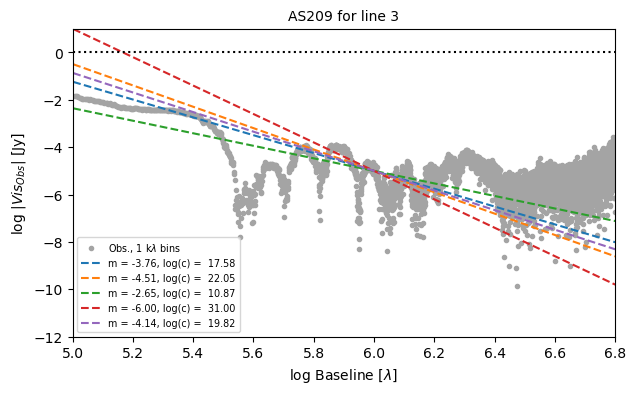

In [198]:
plt.clf()
plt.figure(figsize=(7, 4))
plt.plot(logx, logy, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
for i in range(0, len(m_array)):
    plt.plot(logx, linear(logx, m_array[i], c_array[i]), ls = '--', label = f'm = {m_array[i]: .2f}, log(c) = {logc_array[i]: .2f}')

plt.axhline(0, c='black', ls=':')
plt.title( data_dic['disk_name'] + ' for line '+ str(line+1), size = 10)    
plt.xlabel(r'log Baseline [$\lambda$]', size = 10)
plt.ylabel(r'log $|Vis_{Obs}|$ [Jy]', size = 10)
plt.legend(loc = 'best', fontsize = 'x-small')
plt.ylim(-12, 1)
plt.xlim(5, 6.8)
plt.show()